In [1]:
import io
from pathlib import Path

import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Academic paper style: clean whitegrid, serif fonts, muted palette.
sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "axes.titleweight": "bold",
    "axes.edgecolor": "0.3",
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "legend.frameon": False,
})

FIG_DIR = Path("report/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Consistent colors: HRM-Text is the accent, baselines are muted greys/blues.
ACCENT = "#c0392b"       # HRM-Text
MUTED = "#7f8c8d"        # generic baseline
TRM_COLOR = "#2c6fbb"    # TRM comparison


def save_fig(fig, name):
    """Export a figure as both vector PDF and raster PNG for the paper."""
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}")
    return fig


# Model labels keyed by (config_name, dataset_config); GPT-2 runs are excluded.
MODEL_LABELS = {
    ("hrm_text", "baseline"): "HRM-Text-1B",
    ("hrm_text", "meta-icl"): "HRM-Text-1B (Meta-ICL)",
    ("baseline_1b", "baseline"): "Qwen2.5-1.5B",
    ("meta-icl-1b", "meta-icl"): "Qwen2.5-1.5B (Meta-ICL)",
}

# The 11 GraphQA reasoning tasks (column suffixes in the performance data).
GRAPH_TASKS = [
    "ConnectedNodes", "CycleCheck", "DisconnectedNodes", "EdgeCount",
    "EdgeExistence", "MaximumFlow", "NodeCount", "NodeDegree",
    "Reachability", "ShortestPath", "TriangleCounting",
]


In [2]:
# The W&B export wraps each row in an extra layer of quotes (doubled inner quotes),
# so a plain read_csv collapses everything into one column. Unwrap it first.
def read_wandb_csv(path):
    lines = [ln for ln in Path(path).read_text().splitlines() if ln]
    unwrapped = [
        ln[1:-1].replace('""', '"') if ln.startswith('"') and ln.endswith('"') else ln
        for ln in lines
    ]
    return pd.read_csv(io.StringIO("\n".join(unwrapped)))


performance_data = read_wandb_csv("data/results/performance_data.csv")
ablation_data = read_wandb_csv("data/results/ablation_data.csv")
# Leave-one-task-out OOD: one run per held-out task, per model (grows as new models arrive).
ood_data = read_wandb_csv("data/results/performance_ood_data.csv")


In [3]:
performance_data.head(2)

,Name,State,Notes,User,Tags,Created,Runtime,Sweep,config_name,dataset,...,curriculum/count_CycleCheck,curriculum/count_DisconnectedNodes,curriculum/count_EdgeCount,curriculum/count_EdgeExistence,curriculum/count_MaximumFlow,curriculum/count_NodeCount,curriculum/count_NodeDegree,curriculum/count_Reachability,curriculum/count_ShortestPath,curriculum/count_TriangleCounting
0,baseline-1b-ood-MaximumFlow,finished,-,NaN,NaN,2026-07-29T07:28:12.000Z,73,NaN,baseline_1b,"{'name': 'graphqa', 'test_type': 'ood', 'datas...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,hrm-text-id,finished,-,NaN,NaN,2026-07-29T07:27:57.000Z,15,NaN,hrm_text,"{'name': 'graphqa', 'test_type': 'standard', '...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
ablation_data.head(2)

,Name,State,Notes,User,Tags,Created,Runtime,Sweep,H_cycles,L_cycles,ckpt_path,data,max_generation,ratio_L_over_H,use_ema,eval/accuracy,eval/correct,eval/n
0,graphqa_trm_H1_L12,finished,-,NaN,"H1, L12, ablation, trm",2026-08-03T08:21:23.000Z,7,NaN,1,12,/lustre/fsn1/projects/rech/axa/ugs28gz/graphqa...,data/graphqa/hrm-text/standard/test.jsonl,32,12.0,True,0.509091,196.0,385.0
1,graphqa_H1_L12,finished,-,NaN,"H1, L12, ablation",2026-08-03T07:56:16.000Z,9,NaN,1,12,/lustre/fsn1/projects/rech/axa/ugs28gz/graphqa...,data/graphqa/hrm-text/standard/test.jsonl,32,12.0,True,0.514286,198.0,385.0


# RQ1 — Performance: HRM-Text vs. baselines

Exact-match accuracy on GraphQA. In-distribution (`standard`) results compare HRM-Text-1B
and its Meta-ICL variant against the Qwen2.5-1.5B backbone (direct and Meta-ICL).
Out-of-distribution generalization is measured **leave-one-task-out**: each GraphQA task is
held out in turn and the model evaluated on that unseen task. The OOD figures auto-populate
as more models are added (baseline Qwen and HRM-Text Meta-ICL pending).


In [5]:
# Parse the dict-string `dataset` column to recover test_type and dataset_config,
# then label each run by (config_name, dataset_config) so the HRM-Text Meta-ICL
# variant is kept separate from the direct one.
perf = performance_data.copy()
meta = perf["dataset"].map(eval)
perf["test_type"] = meta.map(lambda d: d["test_type"])
perf["dataset_config"] = meta.map(lambda d: d["dataset_config"])
perf["model"] = [MODEL_LABELS.get((c, d)) for c, d in zip(perf["config_name"], perf["dataset_config"])]
perf = perf.dropna(subset=["model"])
perf = (
    perf.sort_values("Created")
    .drop_duplicates(subset=["model", "test_type"], keep="last")
    .copy()
)
perf_id = perf[perf["test_type"] == "standard"].copy()


def overall_table(df):
    return (
        df[["model", "val/exact_match"]]
        .rename(columns={"val/exact_match": "exact_match"})
        .sort_values("exact_match", ascending=False)
        .reset_index(drop=True)
    )


overall_id = overall_table(perf_id)

# --- OOD: leave-one-task-out (one run per held-out task; auto-includes new models) ---
ood = ood_data.copy()
ood_meta = ood["dataset"].map(eval)
ood["dataset_config"] = ood_meta.map(lambda d: d["dataset_config"])
ood["task"] = ood_meta.map(lambda d: d["ood_task"])
ood["model"] = [MODEL_LABELS.get((c, d)) for c, d in zip(ood["config_name"], ood["dataset_config"])]
ood = ood.dropna(subset=["model"]).copy()
ood["exact_match"] = ood["val/exact_match"].astype(float)
ood = ood.sort_values("Created").drop_duplicates(subset=["model", "task"], keep="last")

# Models x held-out-task matrix (canonical task order) + mean OOD per model for ranking.
ood_by_task = ood.pivot(index="model", columns="task", values="exact_match")
ood_by_task = ood_by_task.reindex(columns=[t for t in GRAPH_TASKS if t in ood_by_task.columns])
overall_ood = (
    ood.groupby("model", as_index=False)["exact_match"]
    .mean()
    .sort_values("exact_match", ascending=False)
    .reset_index(drop=True)
)
overall_id


,model,exact_match
0,HRM-Text-1B,0.833766
1,HRM-Text-1B (Meta-ICL),0.828571
2,Qwen2.5-1.5B,0.719481
3,Qwen2.5-1.5B (Meta-ICL),0.714286


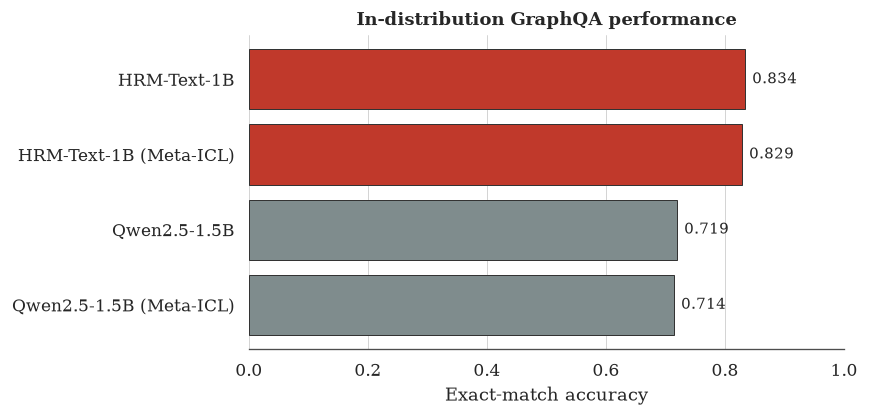

In [6]:
# Reusable overall exact-match bar: HRM-Text variants highlighted, baselines muted.
def plot_overall(table, title, fname):
    fig, ax = plt.subplots(figsize=(6.4, 3.4))
    colors = [ACCENT if m.startswith("HRM-Text") else MUTED for m in table["model"]]
    bars = ax.barh(table["model"], table["exact_match"], color=colors,
                   edgecolor="0.2", linewidth=0.6)
    ax.invert_yaxis()  # best model on top
    ax.set_xlabel("Exact-match accuracy")
    ax.set_xlim(0, 1.0)
    ax.set_title(title)
    for bar, v in zip(bars, table["exact_match"]):
        ax.text(v + 0.012, bar.get_y() + bar.get_height() / 2, f"{v:.3f}",
                va="center", ha="left", fontsize=9)
    sns.despine(ax=ax, left=True)
    ax.grid(axis="y", visible=False)
    save_fig(fig, fname)
    plt.show()


plot_overall(overall_id, "In-distribution GraphQA performance", "perf_overall_id")



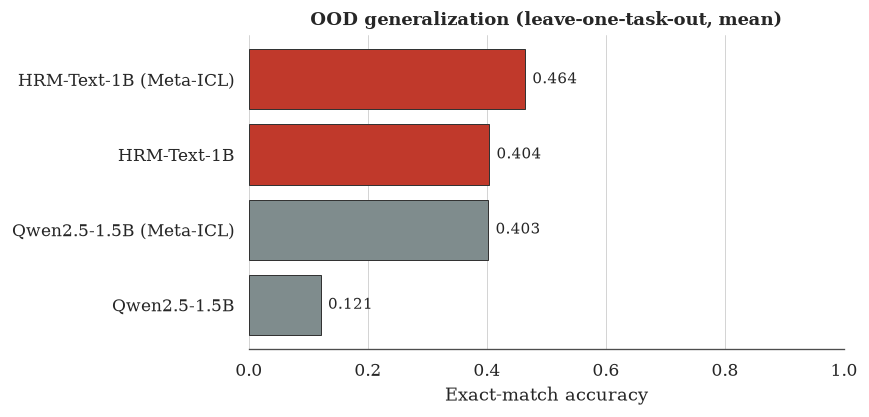

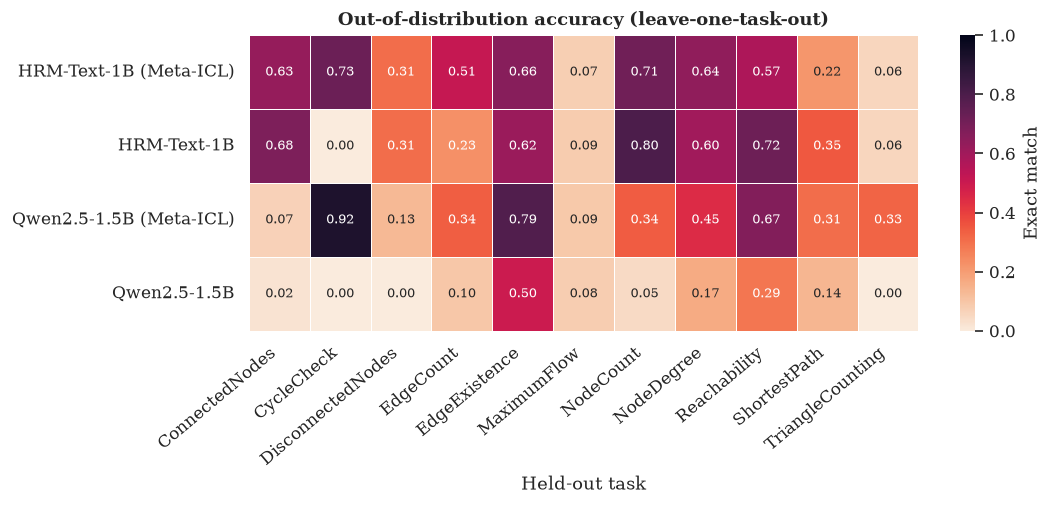

In [ ]:
# Mean OOD accuracy across held-out tasks (bar grows as new models are added).
plot_overall(overall_ood, "OOD generalization (leave-one-task-out, mean)", "perf_overall_ood")

# Per-held-out-task OOD accuracy; figure height adapts to the number of models available.
ood_mat = ood_by_task.reindex(overall_ood["model"])
fig, ax = plt.subplots(figsize=(9.0, 1.0 + 0.55 * len(ood_mat)))
sns.heatmap(
    ood_mat, annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=1,
    linewidths=0.5, linecolor="white", cbar_kws={"label": "Exact match"},
    annot_kws={"fontsize": 8}, ax=ax,
)
ax.set_ylabel("")
ax.set_xlabel("Held-out task")
ax.set_title("Out-of-distribution accuracy (leave-one-task-out)")
plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)
save_fig(fig, "perf_ood_by_task")
plt.show()

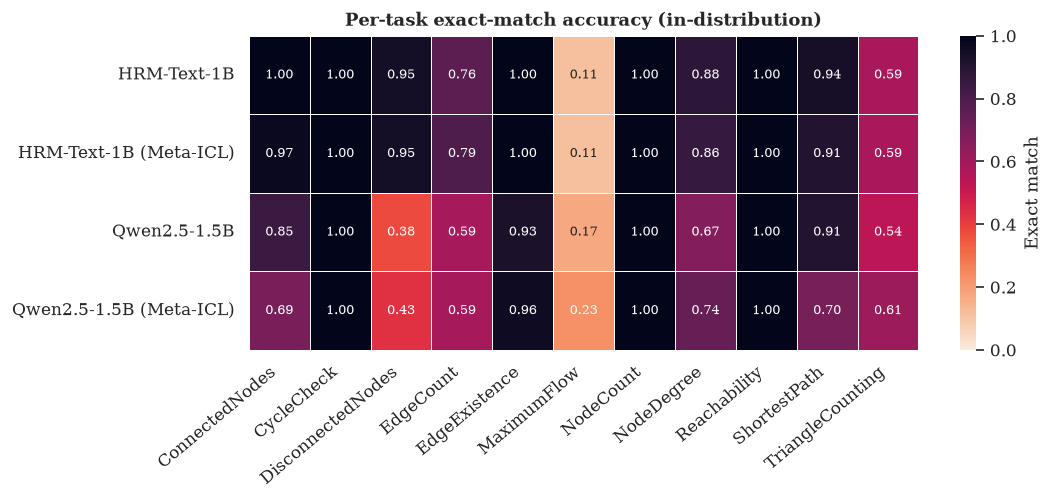

In [8]:
# Per-task exact-match: models x 11 GraphQA tasks (in-distribution).
task_cols = [f"val/exact_match_{t}" for t in GRAPH_TASKS]
bytask = perf_id.set_index("model")[task_cols]
bytask.columns = GRAPH_TASKS
bytask = bytask.reindex(overall_id["model"])  # order by overall accuracy

fig, ax = plt.subplots(figsize=(9.0, 3.4))
sns.heatmap(
    bytask, annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=1,
    linewidths=0.5, linecolor="white", cbar_kws={"label": "Exact match"},
    annot_kws={"fontsize": 8}, ax=ax,
)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("Per-task exact-match accuracy (in-distribution)")
plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)
save_fig(fig, "perf_by_task")
plt.show()


In [9]:
# Generate LaTeX table: transposed (tasks as rows, models as columns) for two-column format.
# Transpose bytask so tasks become rows and models become columns.
latex_table = bytask.T

# Round to 2 decimal places for cleaner display.
latex_table = latex_table.round(2)

# Generate LaTeX with booktabs style.
latex_str = latex_table.to_latex(
    float_format="{:.2f}".format,
    column_format="l|cccc",  # first column (task name) | 4 model columns
    escape=False,
)

print(latex_str)

\begin{tabular}{l|cccc}
\toprule
model & HRM-Text-1B & HRM-Text-1B (Meta-ICL) & Qwen2.5-1.5B & Qwen2.5-1.5B (Meta-ICL) \\
\midrule
ConnectedNodes & 1.00 & 0.97 & 0.85 & 0.69 \\
CycleCheck & 1.00 & 1.00 & 1.00 & 1.00 \\
DisconnectedNodes & 0.95 & 0.95 & 0.38 & 0.43 \\
EdgeCount & 0.76 & 0.79 & 0.59 & 0.59 \\
EdgeExistence & 1.00 & 1.00 & 0.93 & 0.96 \\
MaximumFlow & 0.11 & 0.11 & 0.17 & 0.23 \\
NodeCount & 1.00 & 1.00 & 1.00 & 1.00 \\
NodeDegree & 0.88 & 0.86 & 0.67 & 0.74 \\
Reachability & 1.00 & 1.00 & 1.00 & 1.00 \\
ShortestPath & 0.94 & 0.91 & 0.91 & 0.70 \\
TriangleCounting & 0.59 & 0.59 & 0.54 & 0.61 \\
\bottomrule
\end{tabular}



In [10]:
# LaTeX table for OOD (leave-one-task-out): tasks as rows, models as columns.
ood_latex = ood_by_task.T.reindex(index=GRAPH_TASKS).round(2)

ood_latex_str = ood_latex.to_latex(
    float_format="{:.2f}".format,
    column_format="l|" + "c" * ood_latex.shape[1],
    escape=False,
    na_rep="--",
)

print(ood_latex_str)


\begin{tabular}{l|cccc}
\toprule
model & HRM-Text-1B & HRM-Text-1B (Meta-ICL) & Qwen2.5-1.5B & Qwen2.5-1.5B (Meta-ICL) \\
task &  &  &  &  \\
\midrule
ConnectedNodes & 0.68 & 0.63 & 0.02 & 0.07 \\
CycleCheck & 0.00 & 0.73 & 0.00 & 0.92 \\
DisconnectedNodes & 0.31 & 0.31 & 0.00 & 0.13 \\
EdgeCount & 0.23 & 0.51 & 0.10 & 0.34 \\
EdgeExistence & 0.62 & 0.66 & 0.50 & 0.79 \\
MaximumFlow & 0.09 & 0.07 & 0.08 & 0.09 \\
NodeCount & 0.80 & 0.71 & 0.05 & 0.34 \\
NodeDegree & 0.60 & 0.64 & 0.17 & 0.45 \\
Reachability & 0.72 & 0.57 & 0.29 & 0.67 \\
ShortestPath & 0.35 & 0.22 & 0.14 & 0.31 \\
TriangleCounting & 0.06 & 0.06 & 0.00 & 0.33 \\
\bottomrule
\end{tabular}



In [11]:
# Combined LaTeX table: ID and OOD exact-match per task, two sub-columns per model.
# Every model gets both ID and OOD columns; models without OOD data yet show "--".
models = list(overall_id["model"])
id_tbl = bytask.T.reindex(columns=models)
ood_tbl = ood_by_task.T.reindex(columns=models)
combined = pd.concat(
    {m: pd.DataFrame({"ID": id_tbl[m], "OOD": ood_tbl[m]}) for m in models},
    axis=1,
).reindex(index=GRAPH_TASKS).round(2)

combined_latex_str = combined.to_latex(
    float_format="{:.2f}".format,
    column_format="l|" + "cc" * len(models),
    escape=False,
    na_rep="--",
    multicolumn=True,
    multicolumn_format="c",
)

print(combined_latex_str)


\begin{tabular}{l|cccccccc}
\toprule
 & \multicolumn{2}{c}{HRM-Text-1B} & \multicolumn{2}{c}{HRM-Text-1B (Meta-ICL)} & \multicolumn{2}{c}{Qwen2.5-1.5B} & \multicolumn{2}{c}{Qwen2.5-1.5B (Meta-ICL)} \\
 & ID & OOD & ID & OOD & ID & OOD & ID & OOD \\
\midrule
ConnectedNodes & 1.00 & 0.68 & 0.97 & 0.63 & 0.85 & 0.02 & 0.69 & 0.07 \\
CycleCheck & 1.00 & 0.00 & 1.00 & 0.73 & 1.00 & 0.00 & 1.00 & 0.92 \\
DisconnectedNodes & 0.95 & 0.31 & 0.95 & 0.31 & 0.38 & 0.00 & 0.43 & 0.13 \\
EdgeCount & 0.76 & 0.23 & 0.79 & 0.51 & 0.59 & 0.10 & 0.59 & 0.34 \\
EdgeExistence & 1.00 & 0.62 & 1.00 & 0.66 & 0.93 & 0.50 & 0.96 & 0.79 \\
MaximumFlow & 0.11 & 0.09 & 0.11 & 0.07 & 0.17 & 0.08 & 0.23 & 0.09 \\
NodeCount & 1.00 & 0.80 & 1.00 & 0.71 & 1.00 & 0.05 & 1.00 & 0.34 \\
NodeDegree & 0.88 & 0.60 & 0.86 & 0.64 & 0.67 & 0.17 & 0.74 & 0.45 \\
Reachability & 1.00 & 0.72 & 1.00 & 0.57 & 1.00 & 0.29 & 1.00 & 0.67 \\
ShortestPath & 0.94 & 0.35 & 0.91 & 0.22 & 0.91 & 0.14 & 0.70 & 0.31 \\
TriangleCounting & 0.59 &

# RQ2 — Ablation: the L/H ratio drives performance

Two effects on GraphQA test accuracy, shown for both HRM and TRM:

1. **The L/H ratio is decisive (axis 2).** Raising the low-level-to-high-level cycle
   ratio $L/H$ improves accuracy, peaking at the largest ratio. For HRM, ratios below 1
   collapse performance entirely, whereas TRM is markedly more robust to the ratio.
2. **Pure recursion at a fixed ratio hurts.** Holding $L/H = 1.5$ fixed and simply scaling
   up the number of recurrent cycles degrades accuracy to zero — for both HRM and TRM.


In [12]:
# Clean ablation runs: drop those without an eval score, recompute the true L/H ratio.
abl = ablation_data.copy()
abl = abl[abl["eval/accuracy"].notna()].copy()
abl["accuracy"] = abl["eval/accuracy"].astype(float)
abl["H"] = abl["H_cycles"].astype(int)
abl["L"] = abl["L_cycles"].astype(int)
abl["ratio"] = abl["L"] / abl["H"]
abl["family"] = np.where(abl["Name"].str.contains("trm"), "TRM", "HRM")

# Average any repeated (family, H, L) runs.
abl = (
    abl.groupby(["family", "H", "L", "ratio"], as_index=False)["accuracy"]
    .mean()
    .sort_values(["family", "ratio"])
)
abl


,family,H,L,ratio,accuracy
6,HRM,6,2,0.333333,0.000000
4,HRM,4,3,0.750000,0.062338
3,HRM,3,4,1.333333,0.400000
1,HRM,2,3,1.500000,0.444156
5,HRM,4,6,1.500000,0.054545
7,HRM,6,9,1.500000,0.000000
8,HRM,8,12,1.500000,0.000000
2,HRM,2,6,3.000000,0.438961
0,HRM,1,12,12.000000,0.514286
15,TRM,6,2,0.333333,0.376623


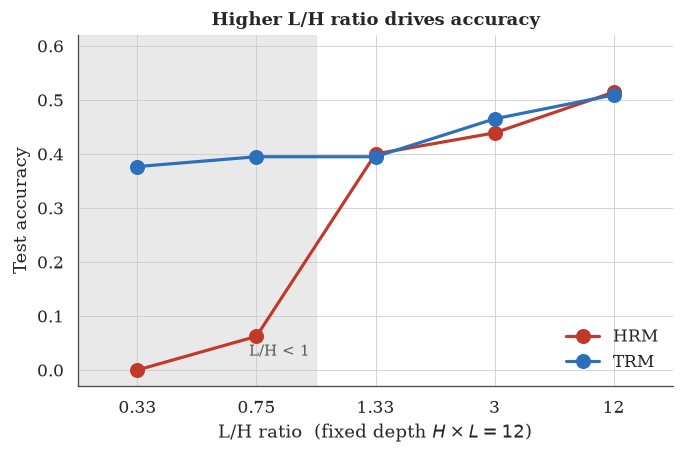

In [15]:
# Axis 2 — ratio effect for HRM and TRM. Hold the total recurrence depth H*L = 12 fixed
# and vary only the L/H ratio. Evenly-spaced x keeps close ratios legible.
def ratio_sweep(family):
    sub = abl[(abl["family"] == family) & (abl["H"] * abl["L"] == 12)]
    return sub.sort_values("ratio").reset_index(drop=True)


hrm_curve = ratio_sweep("HRM")
trm_curve = ratio_sweep("TRM")

# Shared, ordered ratio axis across both families.
ratios = sorted(set(hrm_curve["ratio"]) | set(trm_curve["ratio"]))
pos = {r: i for i, r in enumerate(ratios)}

fig, ax = plt.subplots(figsize=(6.4, 3.8))
n_below = sum(r < 1 for r in ratios)
ax.axvspan(-0.5, n_below - 0.5, color="0.88", alpha=0.7, zorder=0)
ax.text(n_below - 0.55, 0.02, "L/H < 1", fontsize=9, color="0.35", ha="right", va="bottom")

for curve, color, label in [(hrm_curve, ACCENT, "HRM"), (trm_curve, TRM_COLOR, "TRM")]:
    xs = [pos[r] for r in curve["ratio"]]
    ax.plot(xs, curve["accuracy"], marker="o", color=color, markersize=8,
            linewidth=1.9, label=label, zorder=3)

ax.set_xticks(range(len(ratios)))
ax.set_xticklabels([f"{r:.2f}".rstrip("0").rstrip(".") for r in ratios])
ax.set_xlim(-0.5, len(ratios) - 0.5)
ax.set_xlabel("L/H ratio  (fixed depth $H \\times L = 12$)")
ax.set_ylabel("Test accuracy")
ax.set_ylim(-0.03, 0.62)
ax.set_title("Higher L/H ratio drives accuracy")
ax.legend(title="")
sns.despine(ax=ax)
save_fig(fig, "ablation_ratio")
plt.show()


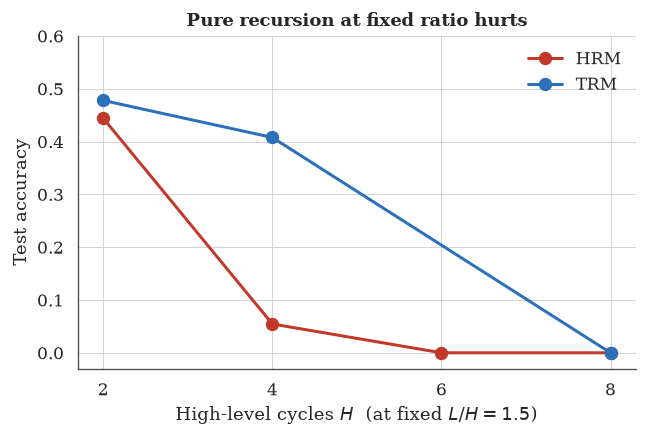

In [14]:
# Fixed-ratio scaling. Hold L/H = 1.5 and increase recurrence depth (H) for HRM and TRM.
fixed = abl[np.isclose(abl["ratio"], 1.5)].sort_values(["family", "H"])

fig, ax = plt.subplots(figsize=(6.0, 3.6))
for fam, color in [("HRM", ACCENT), ("TRM", TRM_COLOR)]:
    sub = fixed[fixed["family"] == fam]
    ax.plot(sub["H"], sub["accuracy"], marker="o", markersize=7, linewidth=1.8,
            color=color, label=fam)

ax.set_xlabel("High-level cycles $H$  (at fixed $L/H = 1.5$)")
ax.set_ylabel("Test accuracy")
ax.set_ylim(-0.03, 0.6)
ax.set_xticks(sorted(fixed["H"].unique()))
ax.set_title("Pure recursion at fixed ratio hurts")
ax.legend(title="")
sns.despine(ax=ax)
save_fig(fig, "ablation_fixed_ratio")
plt.show()
